In [51]:
import pandas as pd
import numpy as np

# Load Dataset
Data=pd.read_csv("../Datasets/Raw_data.csv")

# Explore Data
print(Data.head(5))
print(Data.tail(5))
print(Data.info())
print(Data.describe())
print(Data.shape)
print(Data.isnull().sum())
print(Data.dtypes)


                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  votes                             phone  \
0          Yes        Yes  4.1/5    775    080 42297555\r\n+91 9743772233   
1          Yes         No  4.1/5  

In [52]:
# Drop redundant Columns
Data=Data.drop(['url','address','name','phone','location','reviews_list','menu_item',],axis=1)
Data.shape

# Rename Columns
Data=Data.rename(columns={
    'book_table' : 'Table_booking',
    'rate':'Rating',
    'votes':'No._of_rating',
    'dish_liked':'Bestsellers',
    'approx_cost(for two people)':'Avg._cost(2 person)',
    'listed_in(type)':'Listed_type',
    'listed_in(city)':'Listed_city'
})
print(Data.columns)


Index(['online_order', 'Table_booking', 'Rating', 'No._of_rating', 'rest_type',
       'Bestsellers', 'cuisines', 'Avg._cost(2 person)', 'Listed_type',
       'Listed_city'],
      dtype='object')


In [53]:
# Check Duplicate Values
Duplicates=Data[Data.duplicated]
print(Duplicates.shape)
print(Data.shape)

print(Data[Data.duplicated()])

# create a copy of the dataset

df=Data.copy()



(809, 10)
(51717, 10)
      online_order Table_booking Rating  No._of_rating           rest_type  \
135             No            No    NaN              0  Takeaway, Delivery   
596            Yes           Yes    NEW              0       Casual Dining   
745             No            No    NaN              0         Quick Bites   
746             No            No    NaN              0         Quick Bites   
753             No            No    NEW              0         Quick Bites   
...            ...           ...    ...            ...                 ...   
51627           No            No    NaN              0         Quick Bites   
51638           No            No    NaN              0         Quick Bites   
51642           No            No    NaN              0         Quick Bites   
51643           No            No    NaN              0         Quick Bites   
51644           No            No    NaN              0         Quick Bites   

      Bestsellers                        

In [54]:
# Data Cleaning column by column
print(Data.columns)

# convert 'Yes' and 'No' into 1 and 0
Data['online_order']=Data['online_order'].map({'Yes':1,'No':0})
Data['Table_booking']=Data['Table_booking'].map({'Yes':1,'No':0})


Index(['online_order', 'Table_booking', 'Rating', 'No._of_rating', 'rest_type',
       'Bestsellers', 'cuisines', 'Avg._cost(2 person)', 'Listed_type',
       'Listed_city'],
      dtype='object')


In [55]:
print(Data['online_order'].value_counts())
print(Data['Table_booking'].value_counts())

online_order
1    30444
0    21273
Name: count, dtype: int64
Table_booking
0    45268
1     6449
Name: count, dtype: int64


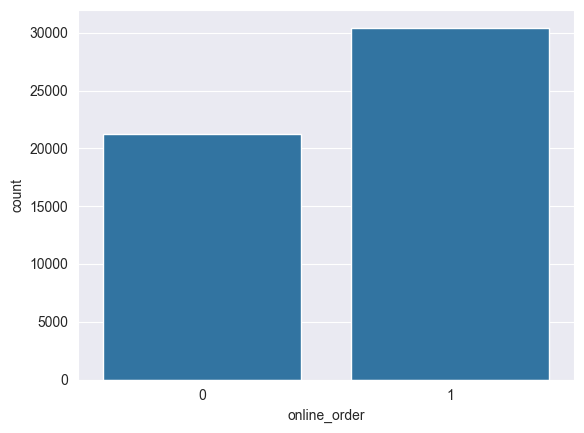

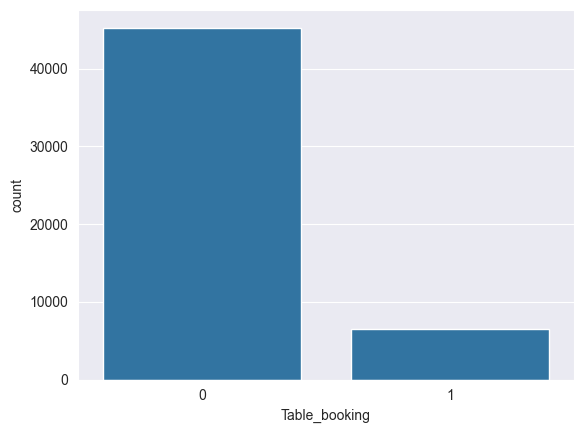

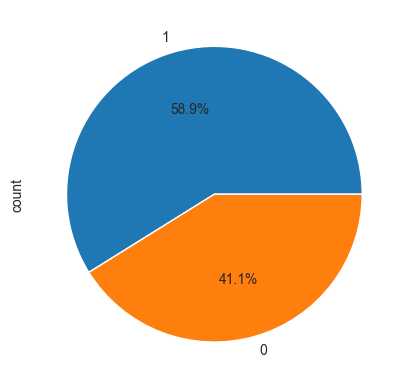

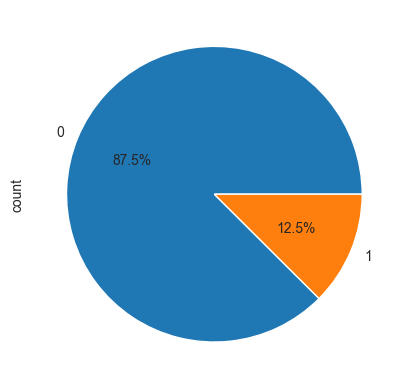

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='online_order',data=Data)
plt.show()
sns.countplot(x='Table_booking',data=Data)
plt.show()
Data['online_order'].value_counts().plot(kind='pie',autopct='%0.1f%%')
plt.show()
Data['Table_booking'].value_counts().plot(kind='pie',autopct='%0.1f%%')
plt.show()
# Data['online_order'].plot(kind='bar')
# plt.show()

In [57]:
print(Data[Data['Rating'].isnull()])
print(Data['Rating'].unique())



       online_order  Table_booking Rating  No._of_rating           rest_type  \
84                0              0    NaN              0         Quick Bites   
90                0              0    NaN              0            Delivery   
91                0              0    NaN              0  Takeaway, Delivery   
92                0              0    NaN              0                Mess   
107               0              0    NaN              0  Takeaway, Delivery   
...             ...            ...    ...            ...                 ...   
51644             0              0    NaN              0         Quick Bites   
51675             0              0    NaN              0                 Bar   
51710             0              0    NaN              0                 Bar   
51713             0              0    NaN              0                 Bar   
51714             0              0    NaN              0                 Bar   

      Bestsellers               cuisine

In [58]:
# First complete the or handle the inaccurate Data
Data['Rating']=Data['Rating'].astype(str)
Data['Rating']=Data['Rating'].replace(['New','-','nan'],np.nan)
Data['Rating']=Data['Rating'].str.replace('/5','',regex=False)
Data['Rating']=Data['Rating'].str.replace(' ','',regex=False)
Data['Rating']=pd.to_numeric(Data['Rating'],errors='coerce')
# coerce helps in converting any invalid value to NAN.

Data['Rating'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

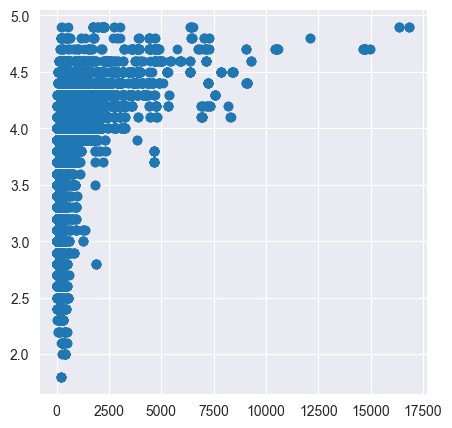

In [59]:

plt.figure(figsize=(5,5))
plt.scatter(Data['No._of_rating'],Data['Rating'])
plt.show()

In [60]:
# Handle Null values

print(Data['Rating'].isnull().sum())
Data['Rating'].fillna(Data['Rating'].median(),inplace=True)
print(Data['Rating'].unique())
print(Data['Rating'].isnull().sum())

10052
[4.1 3.8 3.7 3.6 4.6 4.  4.2 3.9 3.1 3.  3.2 3.3 2.8 4.4 4.3 2.9 3.5 2.6
 3.4 4.5 2.5 2.7 4.7 2.4 2.2 2.3 4.8 4.9 2.1 2.  1.8]
0


C:\Users\Saksham jain\AppData\Local\Temp\ipykernel_18728\234928699.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Data['Rating'].fillna(Data['Rating'].median(),inplace=True)


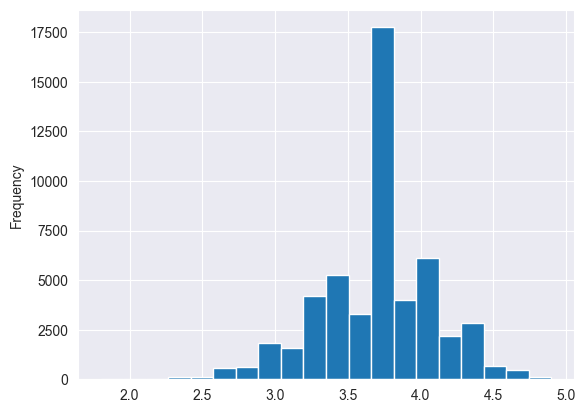

<Axes: xlabel='Rating', ylabel='Count'>

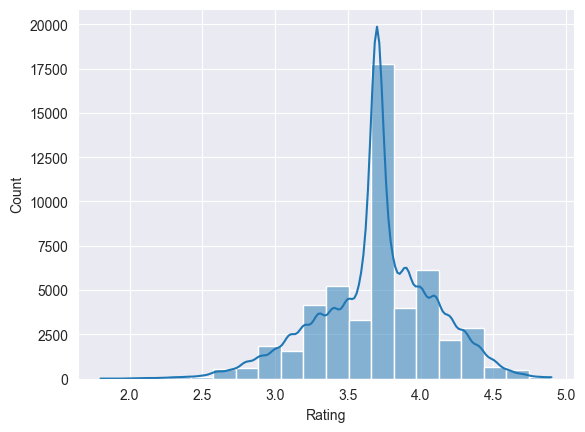

In [61]:
Data['Rating'].plot(kind='hist',bins=20)
plt.show()
sns.histplot(Data['Rating'],bins=20,kde=True)

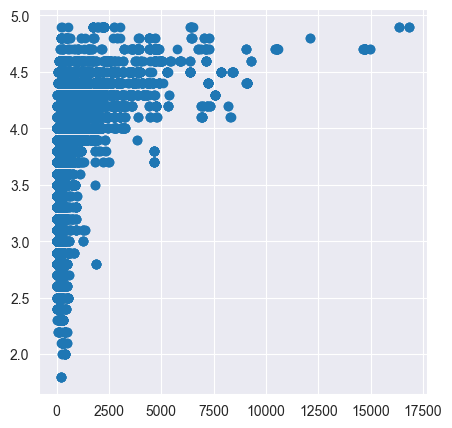

In [62]:
plt.figure(figsize=(5,5))
plt.scatter(Data['No._of_rating'],Data['Rating'])
plt.show()

In [63]:
print(Data['No._of_rating'].isnull().sum())
Data['No._of_rating'].describe()

0


count    51717.000000
mean       283.697527
std        803.838853
min          0.000000
25%          7.000000
50%         41.000000
75%        198.000000
max      16832.000000
Name: No._of_rating, dtype: float64

# Remove Biasness in the Dataset

## WeightedRating(WR)=(v/(v+m))*R + (m/(v+m))*C
- where R = average rating for the book
- v = number of ratings for the book
- m = minimum no. of ratings required to be listed in the best seller list
- C = the mean rating in the dataset

In [64]:
# Rating is baised Because of no. of Raters
# Create a new Column of Weighted Rating

c=Data['Rating'].mean() # Global Avg. Rating
m=Data['No._of_rating'].quantile(0.75) # Minimum rating Threshold

Data['Weighted_Rating'] = (
    (Data['No._of_rating'] / (Data['No._of_rating'] + m)) * Data['Rating']
    + (m / (Data['No._of_rating'] + m)) * c).round(1)

Data.columns

Index(['online_order', 'Table_booking', 'Rating', 'No._of_rating', 'rest_type',
       'Bestsellers', 'cuisines', 'Avg._cost(2 person)', 'Listed_type',
       'Listed_city', 'Weighted_Rating'],
      dtype='object')

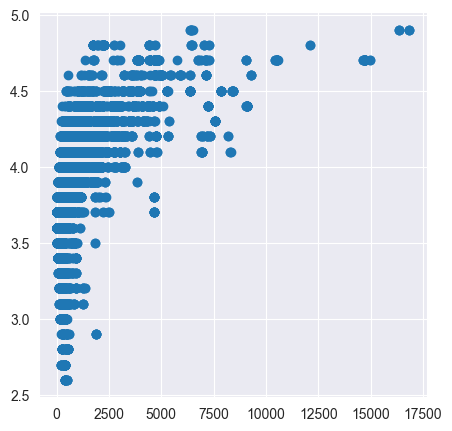

In [65]:
plt.figure(figsize=(5,5))
plt.scatter(Data['No._of_rating'],Data['Weighted_Rating'])
plt.show()

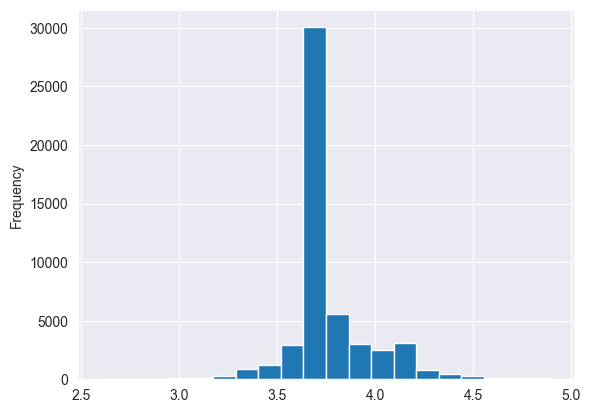

<Axes: xlabel='Weighted_Rating', ylabel='Count'>

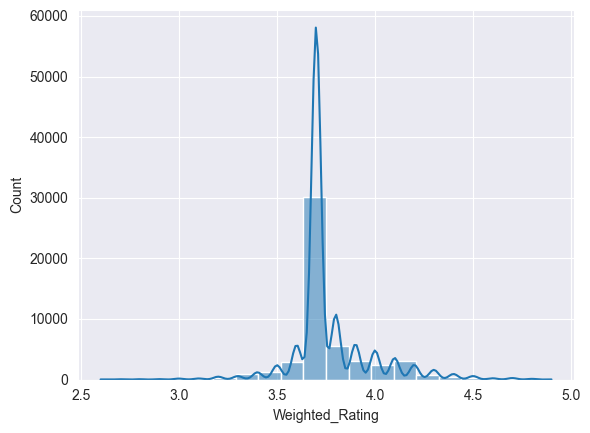

In [66]:
Data['Weighted_Rating'].plot(kind='hist',bins=20)
plt.show()
sns.histplot(Data['Weighted_Rating'],bins=20,kde=True)

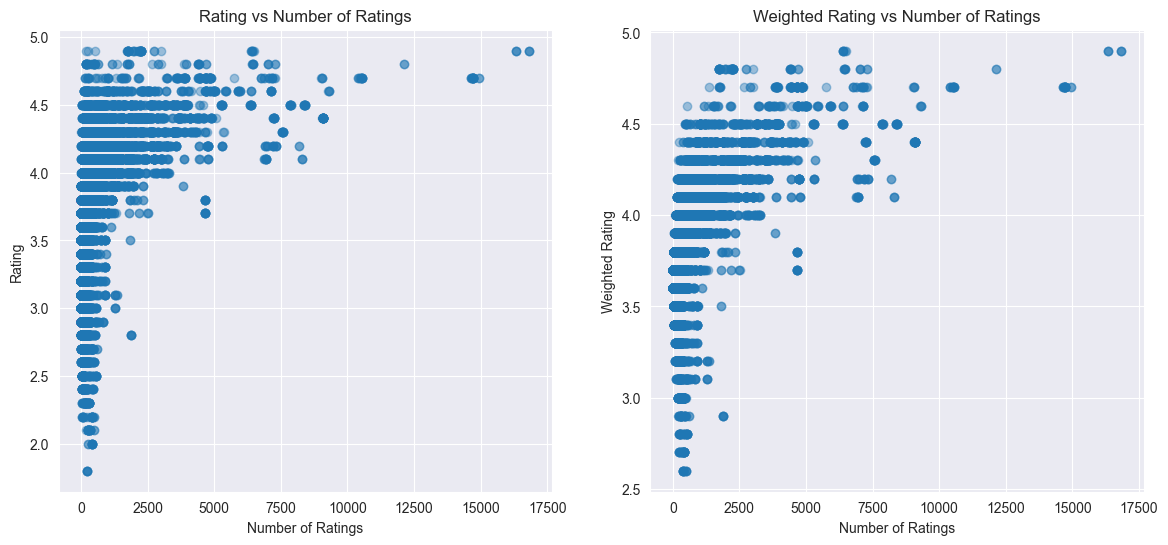

In [67]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.scatter(Data['No._of_rating'], Data['Rating'], alpha=0.4)
plt.xlabel('Number of Ratings')
plt.ylabel('Rating')
plt.title('Rating vs Number of Ratings')

plt.subplot(1,2,2)
plt.scatter(Data['No._of_rating'], Data['Weighted_Rating'], alpha=0.4)
plt.xlabel('Number of Ratings')
plt.ylabel('Weighted Rating')
plt.title('Weighted Rating vs Number of Ratings')

plt.show()


In [68]:
print(Data['rest_type'].isna().sum())
Data['rest_type'] = Data['rest_type'].fillna('Unknown')
Data['rest_type'] = Data['rest_type'].astype(str)
print(Data['rest_type'].isna().sum())
print(Data['rest_type'].unique())

227
0
['Casual Dining' 'Cafe, Casual Dining' 'Quick Bites' 'Casual Dining, Cafe'
 'Cafe' 'Quick Bites, Cafe' 'Cafe, Quick Bites' 'Delivery' 'Mess'
 'Dessert Parlor' 'Bakery, Dessert Parlor' 'Pub' 'Bakery'
 'Takeaway, Delivery' 'Fine Dining' 'Beverage Shop' 'Sweet Shop' 'Bar'
 'Beverage Shop, Quick Bites' 'Confectionery' 'Quick Bites, Beverage Shop'
 'Dessert Parlor, Sweet Shop' 'Bakery, Quick Bites'
 'Sweet Shop, Quick Bites' 'Kiosk' 'Food Truck'
 'Quick Bites, Dessert Parlor' 'Beverage Shop, Dessert Parlor' 'Takeaway'
 'Pub, Casual Dining' 'Casual Dining, Bar' 'Dessert Parlor, Beverage Shop'
 'Quick Bites, Bakery' 'Dessert Parlor, Quick Bites'
 'Microbrewery, Casual Dining' 'Lounge' 'Bar, Casual Dining' 'Food Court'
 'Cafe, Bakery' 'Unknown' 'Dhaba' 'Quick Bites, Sweet Shop' 'Microbrewery'
 'Food Court, Quick Bites' 'Pub, Bar' 'Casual Dining, Pub' 'Lounge, Bar'
 'Food Court, Dessert Parlor' 'Casual Dining, Sweet Shop'
 'Food Court, Casual Dining' 'Casual Dining, Microbrewery'
 'Sweet 

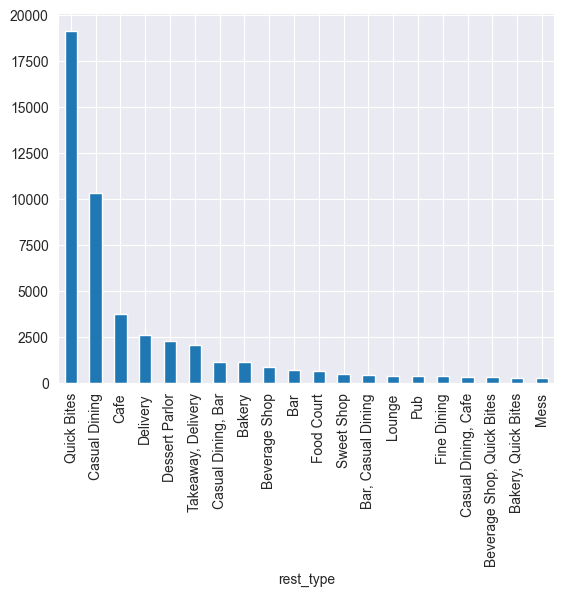

In [69]:
Data['rest_type'].value_counts().head(20).plot(kind='bar')
plt.show()


In [70]:
print(Data['Bestsellers'].unique())
print(Data['Bestsellers'].isnull().sum())

['Pasta, Lunch Buffet, Masala Papad, Paneer Lajawab, Tomato Shorba, Dum Biryani, Sweet Corn Soup'
 'Momos, Lunch Buffet, Chocolate Nirvana, Thai Green Curry, Paneer Tikka, Dum Biryani, Chicken Biryani'
 'Churros, Cannelloni, Minestrone Soup, Hot Chocolate, Pink Sauce Pasta, Salsa, Veg Supreme Pizza'
 ...
 'Noodles, Chicken Noodle, Momos, American Chopsuey, Salad, Manchow Soup, Manchurian'
 'Chicken Quesadilla, Naan, Breakfast Buffet, Cheesecake, Cocktails, Lunch Buffet, Biryani'
 'Biryani, Andhra Meal']
28078


In [71]:
Data['Bestsellers']=Data['Bestsellers'].fillna('No Bestseller Yet')
print(Data['Bestsellers'].isnull().sum())

0


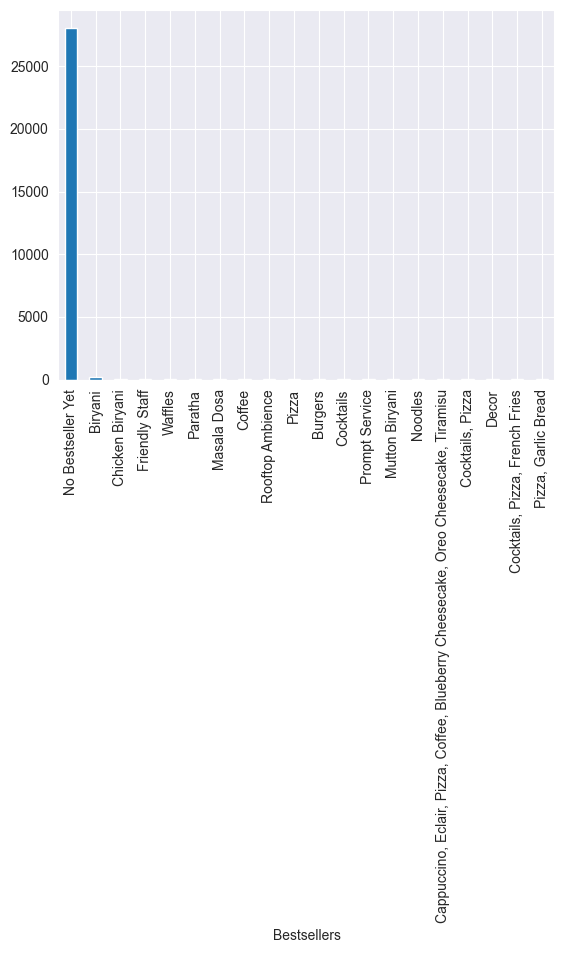

In [72]:
Data['Bestsellers'].value_counts().head(20).plot(kind='bar')
plt.show()

## Drop Bestsellers Feature
- No Distribution
- Mostly Null Value(or No bestseller yet)

In [73]:
Data=Data.drop(['Bestsellers'],axis=1)

In [74]:
print(Data['cuisines'].isnull().sum())
Data['cuisines']=Data['cuisines'].fillna('Unknown')
print(Data['cuisines'].isnull().sum())

45
0


In [75]:
Data['cuisines'].value_counts()

cuisines
North Indian                                 2913
North Indian, Chinese                        2385
South Indian                                 1828
Biryani                                       918
Bakery, Desserts                              911
                                             ... 
Chinese, Biryani, North Indian, Beverages       1
American, Thai, Healthy Food                    1
South Indian, Fast Food, Beverages              1
Chinese, Cafe                                   1
North Indian, Chinese, Arabian, Momos           1
Name: count, Length: 2724, dtype: int64

<Axes: xlabel='cuisines'>

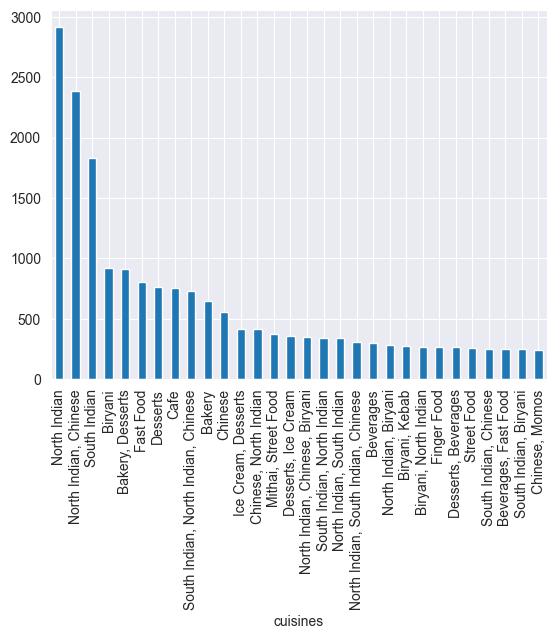

In [76]:
Data['cuisines'].value_counts().head(30).plot(kind='bar')

In [77]:
print(Data['Avg._cost(2 person)'].isnull().sum())
print(Data['Avg._cost(2 person)'].unique())

Data['Avg._cost(2 person)'] = Data['Avg._cost(2 person)'].astype(str).str.replace(",", "")
Data['Avg._cost(2 person)'] = pd.to_numeric(Data['Avg._cost(2 person)'], errors="coerce")

print(Data['Avg._cost(2 person)'].unique())


346
['800' '300' '600' '700' '550' '500' '450' '650' '400' '900' '200' '750'
 '150' '850' '100' '1,200' '350' '250' '950' '1,000' '1,500' '1,300' '199'
 '80' '1,100' '160' '1,600' '230' '130' '50' '190' '1,700' nan '1,400'
 '180' '1,350' '2,200' '2,000' '1,800' '1,900' '330' '2,500' '2,100'
 '3,000' '2,800' '3,400' '40' '1,250' '3,500' '4,000' '2,400' '2,600'
 '120' '1,450' '469' '70' '3,200' '60' '560' '240' '360' '6,000' '1,050'
 '2,300' '4,100' '5,000' '3,700' '1,650' '2,700' '4,500' '140']
[ 800.  300.  600.  700.  550.  500.  450.  650.  400.  900.  200.  750.
  150.  850.  100. 1200.  350.  250.  950. 1000. 1500. 1300.  199.   80.
 1100.  160. 1600.  230.  130.   50.  190. 1700.   nan 1400.  180. 1350.
 2200. 2000. 1800. 1900.  330. 2500. 2100. 3000. 2800. 3400.   40. 1250.
 3500. 4000. 2400. 2600.  120. 1450.  469.   70. 3200.   60.  560.  240.
  360. 6000. 1050. 2300. 4100. 5000. 3700. 1650. 2700. 4500.  140.]


<Axes: xlabel='Avg._cost(2 person)', ylabel='Count'>

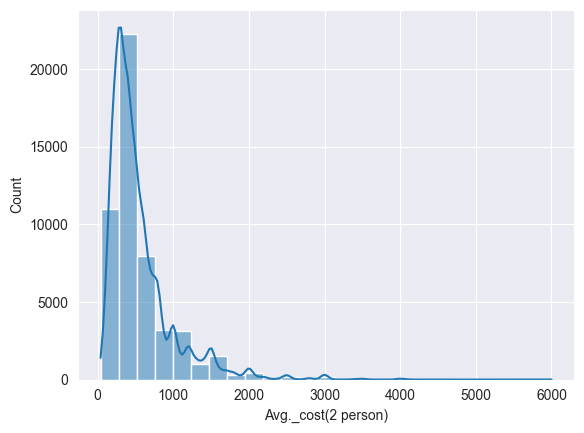

In [78]:
sns.histplot(Data['Avg._cost(2 person)'],bins=25,kde=True)

In [79]:
Data['Avg._cost(2 person)'].skew()

np.float64(2.6019834564289535)

<Axes: xlabel='Avg._cost(2 person)'>

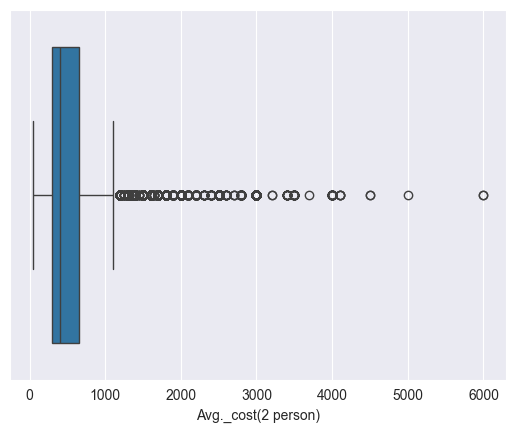

In [80]:
sns.boxplot(x=Data['Avg._cost(2 person)'])

In [81]:
Data['Avg._cost(2 person)']=Data.groupby('rest_type')['Avg._cost(2 person)']\
.transform(lambda x:x.fillna(x.median()))

# Data is highly Skewed
### Solution
- Log Scaling
- It will make the distribution readable and compatible
- It will remove the dominance of Restraunts

In [82]:
Data['Avg_cost(log)'] = np.log1p(Data['Avg._cost(2 person)'])


<Axes: xlabel='Avg_cost(log)', ylabel='Count'>

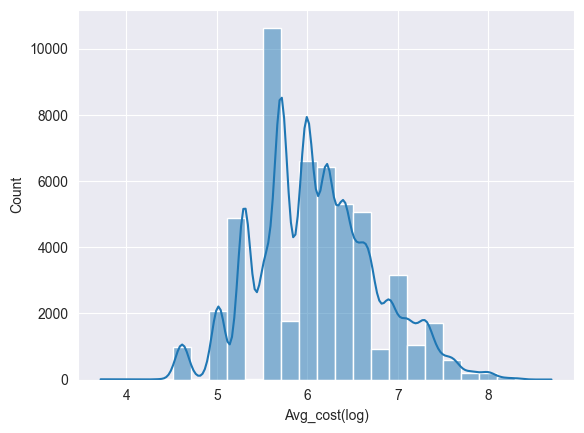

In [83]:
sns.histplot(Data['Avg_cost(log)'],bins=25,kde=True)

In [84]:
Data['Avg_cost(log)'].skew()

np.float64(0.2802018956331337)

In [85]:
Data.columns

Index(['online_order', 'Table_booking', 'Rating', 'No._of_rating', 'rest_type',
       'cuisines', 'Avg._cost(2 person)', 'Listed_type', 'Listed_city',
       'Weighted_Rating', 'Avg_cost(log)'],
      dtype='object')

In [86]:
Data['Listed_type'].isnull().sum()

np.int64(0)

In [87]:
Data['Listed_type'].value_counts()

Listed_type
Delivery              25942
Dine-out              17779
Desserts               3593
Cafes                  1723
Drinks & nightlife     1101
Buffet                  882
Pubs and bars           697
Name: count, dtype: int64

<Axes: xlabel='Listed_type', ylabel='Count'>

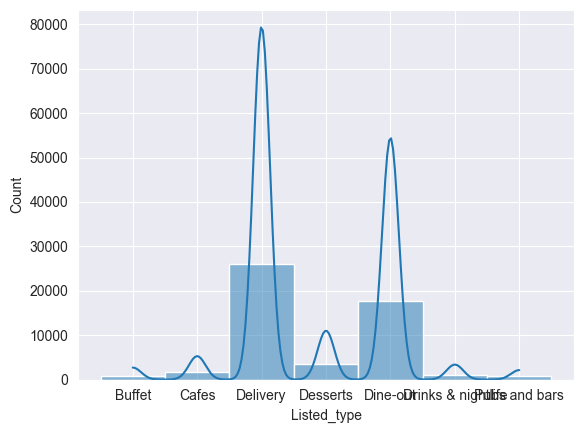

In [88]:
sns.histplot(Data['Listed_type'],bins=20,kde=True)

<Axes: xlabel='Listed_type'>

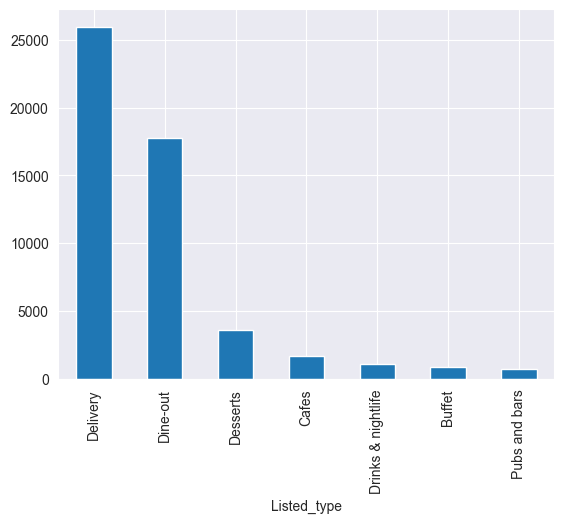

In [89]:
Data['Listed_type'].value_counts().plot(kind='bar')

In [90]:
Data['Listed_city'].isnull().sum()

np.int64(0)

In [91]:
Data['Listed_city'].value_counts()

Listed_city
BTM                      3279
Koramangala 7th Block    2938
Koramangala 5th Block    2836
Koramangala 4th Block    2779
Koramangala 6th Block    2623
Jayanagar                2371
JP Nagar                 2096
Indiranagar              1860
Church Street            1827
MG Road                  1811
Brigade Road             1769
Lavelle Road             1744
HSR                      1741
Marathahalli             1659
Residency Road           1620
Whitefield               1620
Bannerghatta Road        1617
Brookefield              1518
Old Airport Road         1425
Kammanahalli             1329
Kalyan Nagar             1309
Basavanagudi             1266
Sarjapur Road            1261
Electronic City          1229
Bellandur                1227
Frazer Town              1185
Malleshwaram             1096
Rajajinagar              1079
Banashankari              863
New BEL Road              740
Name: count, dtype: int64

<Axes: xlabel='Listed_city'>

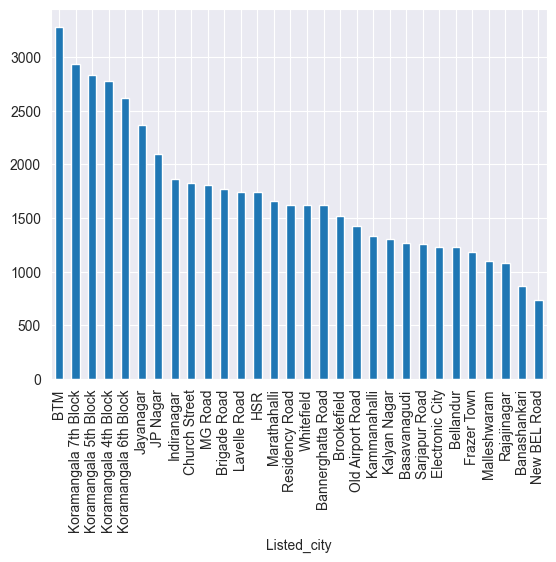

In [92]:
Data['Listed_city'].value_counts().plot(kind='bar')

In [93]:
print(Data.head(5))
print(Data.info())
print(Data.describe())
print(Data.shape)
print(Data.isnull().sum())
print(Data.dtypes)

   online_order  Table_booking  Rating  No._of_rating            rest_type  \
0             1              1     4.1            775        Casual Dining   
1             1              0     4.1            787        Casual Dining   
2             1              0     3.8            918  Cafe, Casual Dining   
3             0              0     3.7             88          Quick Bites   
4             0              0     3.8            166        Casual Dining   

                         cuisines  Avg._cost(2 person) Listed_type  \
0  North Indian, Mughlai, Chinese                800.0      Buffet   
1     Chinese, North Indian, Thai                800.0      Buffet   
2          Cafe, Mexican, Italian                800.0      Buffet   
3      South Indian, North Indian                300.0      Buffet   
4        North Indian, Rajasthani                600.0      Buffet   

    Listed_city  Weighted_Rating  Avg_cost(log)  
0  Banashankari              4.0       6.685861  
1  Banasha

In [94]:
Data['No_of_rating_log'] = np.log1p(Data['No._of_rating']).round(1)


In [96]:
Data.to_csv('../Datasets/Clean_data.csv')
Data.to_pickle('../Datasets/Clean_data.pkl')
